In [5]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np  
# import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [6]:
data = pd.read_csv('clean_sleep_marks_100_students.csv')

In [7]:
data.isnull().sum()

Student_ID     0
Sleep_Hours    0
Marks          0
dtype: int64

In [8]:
data.sample(5)

,Student_ID,Sleep_Hours,Marks
10,11,4.1,45.6
77,78,4.4,45.2
35,36,8.0,79.9
36,37,5.5,55.3
92,93,7.8,76.8


In [9]:
x = data[["Sleep_Hours"]]
y = data[["Marks"]]

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred = model.predict(x_test)

In [13]:
compare = pd.DataFrame({"Actual":y_test.values.flatten(),"Predicted":y_pred.flatten()}) 
print(compare)

    Actual  Predicted
0     46.3  43.796887
1     82.5  83.815463
2     72.8  78.098524
3     68.5  72.381584
4     57.0  53.325119
5     63.5  61.900528
6     55.0  55.230766
7     92.3  81.909817
8     45.6  41.891240
9     59.4  59.042059
10    60.0  61.900528
11    79.4  69.523114
12    82.5  80.004170
13    86.6  85.721110
14    50.1  46.655356
15    46.9  48.561003
16    75.6  78.098524
17    45.2  44.749710
18    79.4  80.956993
19    49.9  49.513826


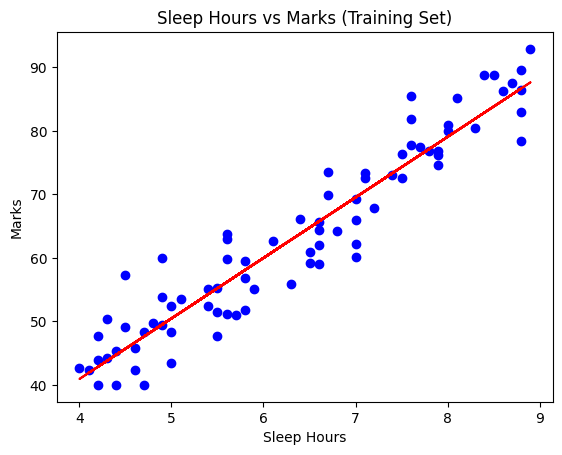

In [14]:
plt.scatter(x_train,y_train,color="blue")
plt.plot(x_train,model.predict(x_train),color="red")
plt.title("Sleep Hours vs Marks (Training Set)")
plt.xlabel("Sleep Hours")
plt.ylabel("Marks")
plt.show()